# Reading Wave file


In [3]:
import struct

def lire_entete_wav(fichier):
    """Lit l'en-tête d'un fichier WAV et retourne les métadonnées."""
    riff = fichier.read(4)  # "RIFF"
    taille_fichier = struct.unpack("<I", fichier.read(4))[0]  # Taille du fichier
    wave = fichier.read(4)  # "WAVE"

    if riff != b"RIFF" or wave != b"WAVE":
        raise ValueError("Ce fichier n'est pas un WAV valide.")

    return taille_fichier

def lire_format_wav(fichier):
    """Lit les informations du format audio."""
    fmt = fichier.read(4)  # "fmt "
    taille_fmt = struct.unpack("<I", fichier.read(4))[0]  # Taille du chunk fmt
    format_audio = struct.unpack("<H", fichier.read(2))[0]  # Format audio (1 = PCM)
    nb_canaux = struct.unpack("<H", fichier.read(2))[0]  # Nombre de canaux
    frequence_echantillonnage = struct.unpack("<I", fichier.read(4))[0]  # Fréquence d'échantillonnage
    taux_octet = struct.unpack("<I", fichier.read(4))[0]  # Byte rate (taux de transfert)
    alignement_bloc = struct.unpack("<H", fichier.read(2))[0]  # Alignement des blocs
    bits_par_echantillon = struct.unpack("<H", fichier.read(2))[0]  # Bits par échantillon

    # Ignorer les éventuels octets supplémentaires
    fichier.read(taille_fmt - 16)

    return {
        "format_audio": format_audio,
        "nb_canaux": nb_canaux,
        "frequence_echantillonnage": frequence_echantillonnage,
        "taux_octet": taux_octet,
        "alignement_bloc": alignement_bloc,
        "bits_par_echantillon": bits_par_echantillon
    }

def trouver_bloc_donnees(fichier):
    """Trouve et se positionne au début du bloc 'data'."""
    while True:
        id_bloc = fichier.read(4)
        # print(id_bloc)
        taille_bloc = struct.unpack("<I", fichier.read(4))[0]

        if id_bloc == b"data":
            return taille_bloc

        fichier.read(taille_bloc)

def lire_donnees_wav(fichier, nb_echantillons, bits_par_echantillon):
    """Lit et convertit les données audio en valeurs numériques."""
    donnees_brutes = fichier.read(nb_echantillons * (bits_par_echantillon // 8))

    format_struct = f"<{nb_echantillons}h" if bits_par_echantillon == 16 else f"<{nb_echantillons}B"
    return struct.unpack(format_struct, donnees_brutes)

def lire_wav(nom_fichier):
    """Lecture complète d'un fichier WAV et extraction des données."""
    with open(nom_fichier, "rb") as fichier:
        taille_fichier = lire_entete_wav(fichier)
        info_format = lire_format_wav(fichier)
        taille_donnees = trouver_bloc_donnees(fichier)

        nb_echantillons = taille_donnees // (info_format["bits_par_echantillon"] // 8)
        donnees_audio = lire_donnees_wav(fichier, nb_echantillons, info_format["bits_par_echantillon"])

        return {
            "taille_fichier": taille_fichier,
            **info_format,
            "nb_echantillons": nb_echantillons,
            "donnees_audio": donnees_audio
        }

info_wav = lire_wav("whistle/whistling-staircase.wav")
print(f"Canaux: {info_wav['nb_canaux']}, Fréquence: {info_wav['frequence_echantillonnage']} Hz")
print(f"Nombre d'échantillons: {info_wav['donnees_audio']}")


b'data'


# Saving wave file


In [8]:

def sauver_wav(chemin_fichier, frequence_echantillonnage, bits_par_echantillon, echantillons):
    """Sauvegarde un fichier WAV mono en PCM avec struct uniquement."""
    with open(chemin_fichier, 'wb') as fichier:
        nb_canaux = 1
        octets_par_echantillon = bits_par_echantillon // 8
        nb_echantillons = len(echantillons)
        taille_donnees = nb_echantillons * octets_par_echantillon
        taille_fichier = 36 + taille_donnees

        fichier.write(b'RIFF')
        fichier.write(struct.pack('<I', taille_fichier))  # Taille totale du fichier
        fichier.write(b'WAVE')

        fichier.write(b'fmt ')
        fichier.write(struct.pack('<I', 16))  # Taille du chunk fmt (16 pour PCM)
        fichier.write(struct.pack('<H', 1))  # Format audio PCM (1)
        fichier.write(struct.pack('<H', nb_canaux))  # Nombre de canaux (1 = mono)
        fichier.write(struct.pack('<I', frequence_echantillonnage))  # Fréquence d'échantillonnage
        fichier.write(struct.pack('<I', frequence_echantillonnage * nb_canaux * octets_par_echantillon))  # Byte rate
        fichier.write(struct.pack('<H', nb_canaux * octets_par_echantillon))  # Alignement des blocs
        fichier.write(struct.pack('<H', bits_par_echantillon))  # Bits par échantillon

        fichier.write(b'data')
        fichier.write(struct.pack('<I', taille_donnees))  # Taille des données

        for echantillon in echantillons:
            if bits_par_echantillon == 8:
                fichier.write(struct.pack('<B', echantillon + 128))  # Convertir en non signé
            else:
                fichier.write(struct.pack('<h', echantillon))

# Amplification

b'data'


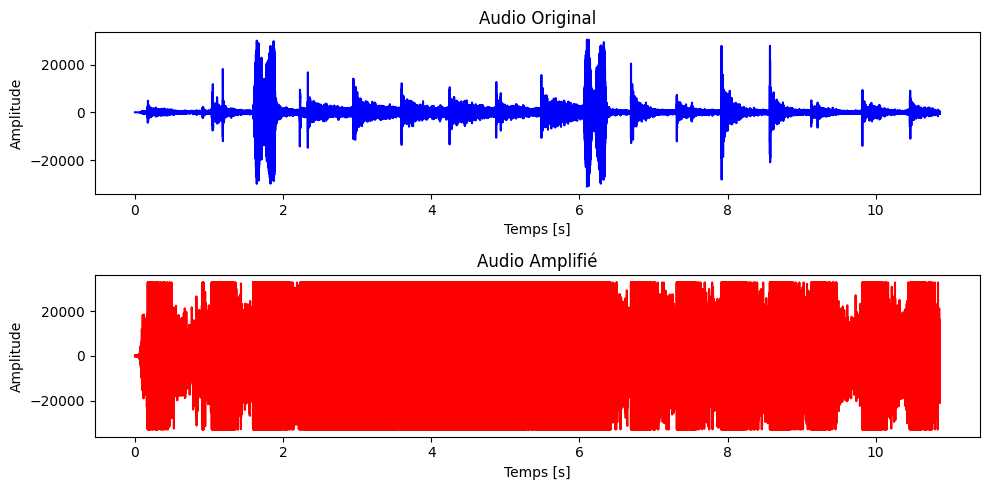

Fichier WAV amplifié sauvegardé sous : audio_amplifie.wav


In [42]:
import matplotlib.pyplot as plt
import numpy as np
def amplifier_audio(chemin_fichier, facteur_amplification=3, fichier_sortie="audio_amplifie.wav"):
    """Amplifie un fichier audio et affiche les courbes avant/après."""
    audio = lire_wav(chemin_fichier)
    taux_echantillonnage, donnees_audio = audio['frequence_echantillonnage'], audio['donnees_audio']

    donnees_amplifiees = np.array(donnees_audio, dtype=np.float32) * facteur_amplification

    valeur_max = 32767
    valeur_min = -32768

    donnees_amplifiees = np.clip(donnees_amplifiees, valeur_min, valeur_max).astype(np.int16)

    axe_x = np.arange(len(donnees_audio)) / taux_echantillonnage
    plt.figure(figsize=(10, 5))

    plt.subplot(2, 1, 1)
    plt.plot(axe_x, donnees_audio, color='blue')
    plt.title("Audio Original")
    plt.xlabel("Temps [s]")
    plt.ylabel("Amplitude")

    plt.subplot(2, 1, 2)
    plt.plot(axe_x, donnees_amplifiees, color='red')
    plt.title("Audio Amplifié")
    plt.xlabel("Temps [s]")
    plt.ylabel("Amplitude")

    plt.tight_layout()
    plt.show()

    sauver_wav(fichier_sortie, taux_echantillonnage, 16, donnees_amplifiees)
    print(f"Fichier WAV amplifié sauvegardé sous : {fichier_sortie}")
amplifier_audio("whistle/whistling-staircase.wav",30)

# Suppresion de bruit
    Méthode : Filtrage adaptif basée sur la corrélation croisée


b'data'
b'data'


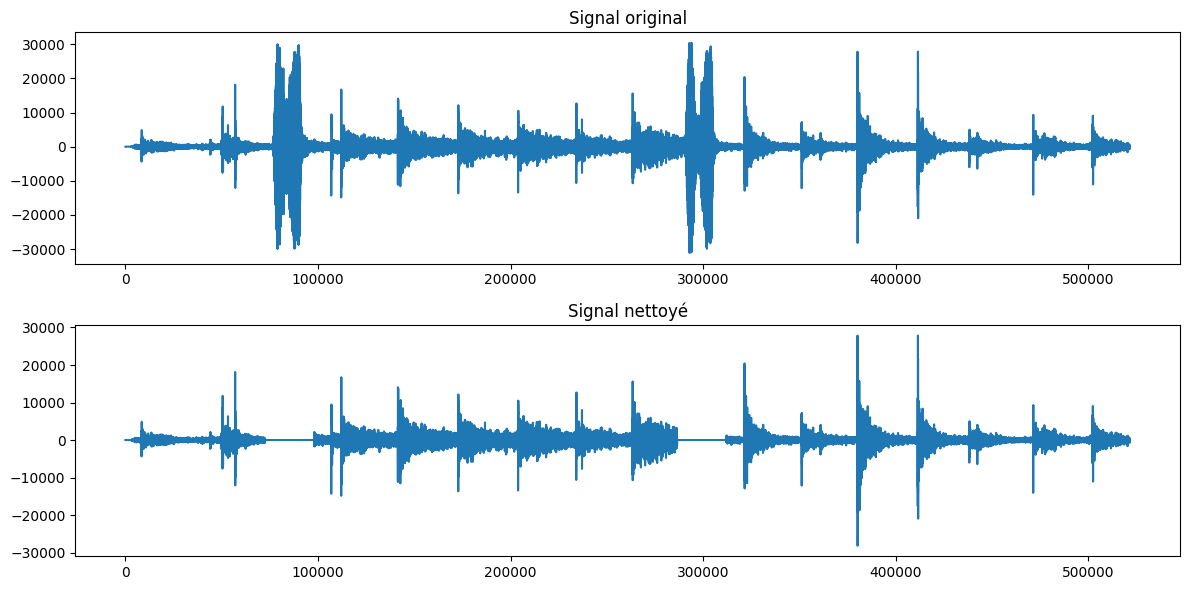

In [35]:

def trouver_tous_bruits(signal, bruit_ref, seuil=0.5):
    """Trouve toutes les positions où le bruit se répète"""
    scores = []
    longueur_bruit = len(bruit_ref)

    for i in range(len(signal) - longueur_bruit):
        morceau = signal[i:i+longueur_bruit]
        score = np.dot(morceau, bruit_ref) / (np.linalg.norm(morceau) * np.linalg.norm(bruit_ref))
        scores.append(score)

    positions = []
    score_max = max(scores)
    for i, score in enumerate(scores):

        if score > seuil * score_max:
            positions.append(i)

    return positions

def supprimer_bruits_repetes(signal, bruit_ref):
    """Supprime toutes les occurrences du bruit"""
    positions = trouver_tous_bruits(signal, bruit_ref)
    signal_propre = signal.copy()

    for pos in positions:
        bruit_ajuste = bruit_ref * 0

        fin = pos + len(bruit_ref)
        if fin > len(signal_propre):
            fin = len(signal_propre)
            bruit_ajuste = bruit_ajuste[:fin-pos]

        signal_propre[pos:fin] = bruit_ajuste.astype(signal_propre.dtype)

    return np.clip(signal_propre, -32768, 32767).astype(np.int16)

def nettoyer(signal_path,bruit_path):
    signal_data = lire_wav(signal_path)
    bruit_data = lire_wav(bruit_path)

    signal = np.array(signal_data["donnees_audio"], dtype=np.float32)
    bruit_ref = np.array(bruit_data["donnees_audio"] , dtype=np.float32)

    resultat = supprimer_bruits_repetes(signal, bruit_ref)

    plt.figure(figsize=(12, 6))
    plt.subplot(2,1,1)
    plt.title("Signal original")
    plt.plot(signal)

    plt.subplot(2,1,2)
    plt.title("Signal nettoyé")
    plt.plot(resultat)
    plt.tight_layout()
    plt.show()
    sauver_wav("audio_filtre_amelioré.wav",
              signal_data["frequence_echantillonnage"],
              16,
              resultat)

def nettoyer_multiple(signal_path,bruit_paths):
    signal_data = lire_wav(signal_path)
    signal = np.array(signal_data["donnees_audio"], dtype=np.float32)
    resultat = signal.copy()
    for i in bruit_paths:
        bruit_data = lire_wav(i)
        bruit_ref = np.array(bruit_data["donnees_audio"] , dtype=np.float32)
        resultat = supprimer_bruits_repetes(resultat, bruit_ref)

    plt.figure(figsize=(12, 6))
    plt.subplot(2,1,1)
    plt.title("Signal original")
    plt.plot(signal)

    plt.subplot(2,1,2)
    plt.title("Signal nettoyé")
    plt.plot(resultat)
    plt.tight_layout()
    plt.show()

    sauver_wav("audio_filtre_amelioré.wav",
              signal_data["frequence_echantillonnage"],
              16,
              resultat)

signal_path = "whistle/whistling-staircase.wav"
bruit_path = "whistle/remove/whistle-simple.wav"

nettoyer(signal_path, bruit_path)


